In [ ]:
# Data analysis aur machine learning ke required libraries import kar rahe hai
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

%matplotlib inline
sns.set(style="whitegrid")

In [ ]:

# Dataset ko CSV file se load kar rahe hai
df = pd.read_csv('DATA/creditcard.csv')
# Amount aur Time column ko normalize karne ke liye StandardScaler use kar rahe hai
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df['Amount'].values.reshape(-1, 1))
df['Time'] = scaler.fit_transform(df['Time'].values.reshape(-1, 1))
# Features (X) aur target variable (y) ko alag kar rahe hai
X = df.drop('Class', axis=1)
y = df['Class']
# Dataset ka size aur class distribution print kar rahe hai
print(f"Dataset Dimensions: {df.shape}")
print(f"Class Distribution:\n{df['Class'].value_counts(normalize=True) * 100}")

Dataset Dimensions: (284807, 31)
Class Distribution:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [ ]:
# Dataset imbalanced hai isliye SMOTE se balance kar rahe hai
print("Balancing dataset using SMOTE...")
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)
# Dataset ko training aur testing data me split kar rahe hai
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
print(f"Training set size: {X_train.shape[0]}")

Balancing dataset using SMOTE...
Training set size: 454904


In [ ]:
# XGBoost classifier model create kar rahe hai aur training kar rahe hai
xgb_model = XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, eval_metric='logloss')
xgb_model.fit(X_train, y_train)
print("Model Training Successfully Completed.")

Model Training Successfully Completed.


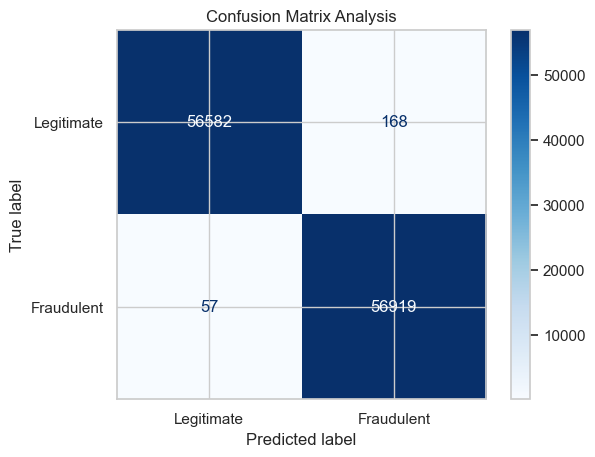


--- Model Performance Metrics ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

ROC-AUC Score: 0.9999


In [ ]:
# Test data par prediction kar rahe hai aur model performance evaluate kar rahe hai
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Fraudulent'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix Analysis")
plt.show()

print("\n--- Model Performance Metrics ---")
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

In [ ]:
# Real-time fraud detection function ,Input transaction ko array format me convert kar rahe hai aur model se prediction kar rahe hai, agar prediction 1 hai to "FLAGGED: Potential Fraud" return kar rahe hai, otherwise "Status: Legitimate" return kar rahe hai.
def run_fraud_check(transaction_vector):
    """Simulates real-time transaction monitoring."""
    tx = np.array(transaction_vector).reshape(1, -1)
    prediction = xgb_model.predict(tx)
    return "FLAGGED: Potential Fraud" if prediction[0] == 1 else "Status: Legitimate"

sample_data = X_test.iloc[0]
print(f"Inference Result: {run_fraud_check(sample_data)}")

Inference Result: FLAGGED: Potential Fraud
